In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [2]:
# 1. Sigmoid and its derivative with SymPy


z = sp.symbols('z')

sigmoid = 1 / (1 + sp.exp(-z))

# Derivative
sigmoid_derivative = sp.diff(sigmoid, z)

# Check: derivative - sigmoid * (1 - sigmoid) = 0
difference = sp.simplify(
    sigmoid_derivative - sigmoid * (1 - sigmoid)
)

print("Sigmoid:")
print(sigmoid)

print("\nSigmoid derivative:")
print(sigmoid_derivative)

print("\nDifference:")
print(difference)


Sigmoid:
1/(1 + exp(-z))

Sigmoid derivative:
exp(-z)/(1 + exp(-z))**2

Difference:
0


In [3]:
# 2. Logistic Regression with Gradient Descent
# x = number of previous purchases
# y = 0 -> customer did not buy
# y = 1 -> customer bought

x = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y = np.array([0, 0, 0, 1, 0, 1, 1, 1])


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


w, b, lr = 0, 0, 0.1

for step in range(2000):

    # Prediction
    p = sigmoid(w * x + b)

    # Gradients
    dw = np.mean((p - y) * x)
    db = np.mean(p - y)

    # Update
    w = w - lr * dw
    b = b - lr * db


print("\nTraining result:")
print(f"w = {w:.4f}")
print(f"b = {b:.4f}")

p = sigmoid(w * x + b)

print("\nPredicted probabilities:")
print(np.round(p, 3))


Training result:
w = 1.1650
b = -5.1976

Predicted probabilities:
[0.017 0.054 0.154 0.369 0.652 0.857 0.951 0.984]


In [4]:
# 3. ROC Curve + AUC
tpr = [0]
fpr = [0]

for t in np.sort(np.unique(p))[::-1]:

    pred = (p >= t).astype(int)

    tp = np.sum((pred == 1) & (y == 1))
    fp = np.sum((pred == 1) & (y == 0))

    fn = np.sum((pred == 0) & (y == 1))
    tn = np.sum((pred == 0) & (y == 0))

    tpr.append(tp / (tp + fn))
    fpr.append(fp / (fp + tn))

tpr.append(1)
fpr.append(1)

tpr = np.array(tpr)
fpr = np.array(fpr)

auc = np.trapezoid(tpr, fpr)

print(f"AUC: {auc:.4f}")

AUC: 0.9375


In [5]:
# Calculate AUC using trapezoid rule
auc = np.trapezoid(tpr, fpr)

print("\nTPR:")
print(np.round(tpr, 3))

print("\nFPR:")
print(np.round(fpr, 3))

print(f"\nAUC by hand: {auc:.4f}")


TPR:
[0.   0.25 0.5  0.75 0.75 1.   1.   1.   1.   1.  ]

FPR:
[0.   0.   0.   0.   0.25 0.25 0.5  0.75 1.   1.  ]

AUC by hand: 0.9375


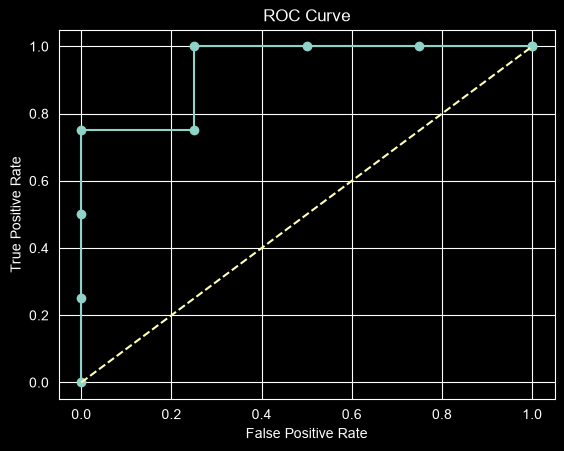

In [6]:
# ROC Curve

plt.plot(fpr, tpr, marker="o")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()